# Evaluate Fine-Tuned Embeddings on Eval Pairs

This notebook loads a fine-tuned E5-Mistral checkpoint and evaluates it on labeled story pairs.

Outputs:
- cosine similarity per pair
- ranking metrics (ROC-AUC, Average Precision)
- threshold metrics (accuracy/F1 at best threshold)
- class-wise similarity stats


In [1]:
from pathlib import Path
import json
import math
import random

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
)

/home/shayan/miniconda3/envs/story_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists() and (PROJECT_ROOT.parent / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

CONFIG = {
    # Data
    'scores_path': PROJECT_ROOT / 'data' / 'Alignment' / 'asq_random_10000_pair_structural_scores.json',
    'alignments_path': PROJECT_ROOT / 'data' / 'Alignment' / 'asq_random_10000_story_pair_alignments.json',
    'output_dir': PROJECT_ROOT / 'artifacts' / 'e5_mistral_structural_finetune',

    # Model
    'model_name': 'intfloat/e5-mistral-7b-instruct',
    'max_length': 1024,
    'use_bfloat16': True,
    'hf_cache_dir': Path('/scratch/shayan/hf_cache'),

    # Training objective: 'infonce' or 'contrastive_mse'
    'loss_type': 'infonce',

    # Optimization
    'seed': 42,
    'train_frac': 0.9,
    'batch_size': 2,
    'num_epochs': 10,
    'lr': 1e-4,
    'weight_decay': 0.01,
    'warmup_ratio': 0.03,
    'grad_accum_steps': 8,
    'max_grad_norm': 1.0,
    'temperature': 0.05,

    # Pair bucket sampling strategy
    'hard_negative_bin': 2,
    'positive_bin': 3,
    'easy_negative_bins': [0, 1],
    'max_triplets_per_anchor': 8,

    # LoRA
    'lora_r': 16,
    'lora_alpha': 32,
    'lora_dropout': 0.05,
    'target_modules': ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],

    # Logging
    'eval_every_steps': 100,
}

# User-specified checkpoint
CHECKPOINT_PATH = Path('/scratch/shayan/Projects/NarrativeSimilarity/artifacts/e5_mistral_structural_finetune/checkpoints/epoch_02')

# Eval set from previous prep
EVAL_PAIRS_PATH = PROJECT_ROOT / 'data' / 'eval_data' / 'eval_story_pairs_200.csv'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE = torch.bfloat16 if (CONFIG['use_bfloat16'] and DEVICE == 'cuda') else torch.float32

print('PROJECT_ROOT     :', PROJECT_ROOT)
print('EVAL_PAIRS_PATH  :', EVAL_PAIRS_PATH)
print('CHECKPOINT_PATH  :', CHECKPOINT_PATH)
print('DEVICE           :', DEVICE)
print('DTYPE            :', DTYPE)


PROJECT_ROOT     : /tank/scratch/shayan/Projects/NarrativeSimilarity
EVAL_PAIRS_PATH  : /tank/scratch/shayan/Projects/NarrativeSimilarity/data/eval_data/eval_story_pairs_200.csv
CHECKPOINT_PATH  : /scratch/shayan/Projects/NarrativeSimilarity/artifacts/e5_mistral_structural_finetune/checkpoints/epoch_02
DEVICE           : cuda
DTYPE            : torch.bfloat16


In [20]:
if not EVAL_PAIRS_PATH.exists():
    raise FileNotFoundError(f'Eval pairs file not found: {EVAL_PAIRS_PATH}')

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f'Checkpoint path not found: {CHECKPOINT_PATH}\n'
        'Update CHECKPOINT_PATH to your trained checkpoint directory.'
    )

eval_df = pd.read_csv(EVAL_PAIRS_PATH).copy()
required_cols = ['pair_id', 'story_text_a', 'story_text_b', 'label']
missing = [c for c in required_cols if c not in eval_df.columns]
if missing:
    raise ValueError(f'Missing required columns in eval data: {missing}')

eval_df['label'] = eval_df['label'].astype(int)
print('Loaded eval pairs:', len(eval_df))
print(eval_df['label'].value_counts().rename(index={0:'negative',1:'positive'}).to_string())

eval_df.head(3)


Loaded eval pairs: 200
label
negative    100
positive    100


,dataset,pair_type,group_a,group_b,story_id_a,story_id_b,story_text_a,story_text_b,label,pair_id
0,tell_me_again,random_negative,174284,461447,174284_5,461447_6,"In 1936, archaeology professor and adventurer ...",Amelia Earhart was an American aviation pionee...,0,tell_me_again__0000
1,tell_me_again,random_negative,111018582,11618,111018582_4,11618_6,"Young Alfred ""Al"" Yankovic is interested in pa...","# General presentation\nIn an industrial town,...",0,tell_me_again__0001
2,tell_me_again,random_negative,323401,1398816,323401_0,1398816_0,"In 1874, the U.S. government encroaches on the...",Mark Dixon is a police detective who was just ...,0,tell_me_again__0002


In [5]:
# Load tokenizer + fine-tuned model checkpoint
# This assumes checkpoint directory is in HuggingFace format (e.g. saved via save_pretrained).

tokenizer = AutoTokenizer.from_pretrained(
    str(CHECKPOINT_PATH),
    trust_remote_code=True,
    cache_dir=str(CONFIG['hf_cache_dir']),
)

model = AutoModel.from_pretrained(
    str(CHECKPOINT_PATH),
    trust_remote_code=True,
    cache_dir=str(CONFIG['hf_cache_dir']),
    dtype=DTYPE,
)
model.to(DEVICE)
model.eval()

print('Loaded model from checkpoint:', CHECKPOINT_PATH)

Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.59it/s]


Loaded model from checkpoint: /scratch/shayan/Projects/NarrativeSimilarity/artifacts/e5_mistral_structural_finetune/checkpoints/epoch_02


In [22]:
# E5-style text formatting + mean pooling
# E5 generally benefits from explicit task prefix.

from tqdm import tqdm

def to_query_text(story: str) -> str:
    return f'query: retrieve stories with a similar narrative to the given story. {story}'


def mean_pool(last_hidden_state: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    mask = attention_mask.unsqueeze(-1).to(last_hidden_state.dtype)
    summed = (last_hidden_state * mask).sum(dim=1)
    denom = mask.sum(dim=1).clamp(min=1e-9)
    return summed / denom


@torch.no_grad()
def embed_texts(texts, batch_size=8):
    all_emb = []
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Embedding", unit="batch"):
        batch = texts[i:i+batch_size]
        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=CONFIG['max_length'],
            return_tensors='pt',
        )
        enc = {k: v.to(DEVICE) for k, v in enc.items()}

        out = model(**enc)
        pooled = mean_pool(out.last_hidden_state, enc['attention_mask'])
        pooled = F.normalize(pooled, p=2, dim=1)
        all_emb.append(pooled.detach().float().cpu())

    return torch.cat(all_emb, dim=0)

In [10]:
texts_a = [to_query_text(str(x)) for x in eval_df['story_text_a'].tolist()]
texts_b = [to_query_text(str(x)) for x in eval_df['story_text_b'].tolist()]

emb_a = embed_texts(texts_a, batch_size=8)
emb_b = embed_texts(texts_b, batch_size=8)

cos_scores = (emb_a * emb_b).sum(dim=1).numpy()
eval_df['cosine_similarity'] = cos_scores

print('Computed cosine scores for', len(eval_df), 'pairs')
eval_df[['pair_id', 'label', 'cosine_similarity']].head(10)

Embedding: 100%|██████████| 25/25 [00:39<00:00,  1.56s/batch]

Computed cosine scores for 200 pairs


,pair_id,label,cosine_similarity
0,tell_me_again__0000,0,0.396314
1,tell_me_again__0001,1,0.605290
2,tell_me_again__0002,1,0.299310
3,tell_me_again__0003,0,0.630799
4,tell_me_again__0004,1,0.405932
5,tell_me_again__0005,1,0.729984
6,tell_me_again__0006,1,0.305817
7,tell_me_again__0007,1,0.414005
8,tell_me_again__0008,0,0.515344
9,tell_me_again__0009,0,0.517511


In [11]:
y_true = eval_df['label'].to_numpy(dtype=int)
y_score = eval_df['cosine_similarity'].to_numpy(dtype=float)

metrics = {}

# Ranking metrics
metrics['roc_auc'] = float(roc_auc_score(y_true, y_score))
metrics['average_precision'] = float(average_precision_score(y_true, y_score))

# Best-threshold metrics (maximize F1)
thresholds = np.unique(y_score)
best = {'threshold': None, 'f1': -1.0, 'accuracy': None, 'precision': None, 'recall': None}

for t in thresholds:
    y_pred = (y_score >= t).astype(int)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    if f1 > best['f1']:
        p, r, _, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
        acc = accuracy_score(y_true, y_pred)
        best.update({'threshold': float(t), 'f1': float(f1), 'accuracy': float(acc), 'precision': float(p), 'recall': float(r)})

metrics['best_threshold'] = best

# Class-wise score stats
by_label = eval_df.groupby('label')['cosine_similarity'].agg(['count', 'mean', 'std', 'min', 'max'])
by_label.index = by_label.index.map({0: 'negative', 1: 'positive'})

print('=== Ranking Metrics ===')
print(json.dumps({'roc_auc': metrics['roc_auc'], 'average_precision': metrics['average_precision']}, indent=2))

print('\n=== Best Threshold Metrics (max F1) ===')
print(json.dumps(best, indent=2))

print('\n=== Cosine Similarity by Class ===')
print(by_label.round(6).to_string())


=== Ranking Metrics ===
{
  "roc_auc": 0.6351,
  "average_precision": 0.7880577848914472
}

=== Best Threshold Metrics (max F1) ===
{
  "threshold": 0.6620538234710693,
  "f1": 0.7295597484276729,
  "accuracy": 0.785,
  "precision": 0.9830508474576272,
  "recall": 0.58
}

=== Cosine Similarity by Class ===
          count      mean       std       min       max
label                                                  
negative    100  0.527234  0.078061  0.358408  0.697782
positive    100  0.619901  0.229701  0.194324  0.989040


In [12]:
# Optional: persist per-pair scores + aggregate metrics
OUT_DIR = PROJECT_ROOT / 'data' / 'eval_results'
OUT_DIR.mkdir(parents=True, exist_ok=True)

pair_scores_path = OUT_DIR / 'embedding_eval_pair_scores.csv'
metrics_path = OUT_DIR / 'embedding_eval_metrics.json'

eval_df.to_csv(pair_scores_path, index=False)
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(
        {
            'checkpoint_path': str(CHECKPOINT_PATH),
            'model_name': CONFIG['model_name'],
            'loss_type': CONFIG['loss_type'],
            'num_pairs': int(len(eval_df)),
            'num_positive': int((eval_df['label'] == 1).sum()),
            'num_negative': int((eval_df['label'] == 0).sum()),
            'roc_auc': metrics['roc_auc'],
            'average_precision': metrics['average_precision'],
            'best_threshold': metrics['best_threshold'],
        },
        f,
        indent=2,
    )

print('Saved pair scores:', pair_scores_path)
print('Saved metrics    :', metrics_path)

Saved pair scores: /tank/scratch/shayan/Projects/NarrativeSimilarity/data/eval_results/embedding_eval_pair_scores.csv
Saved metrics    : /tank/scratch/shayan/Projects/NarrativeSimilarity/data/eval_results/embedding_eval_metrics.json


## Multi-Checkpoint Evaluation Pipeline

This section adds a lightweight evaluation pipeline to compare multiple saved checkpoints (`epoch_02`, `epoch_04`, ..., `epoch_10`) on the same eval set.

Why this helps:
- We keep one fixed evaluation dataset and metric definition.
- We run identical embedding + cosine scoring for each checkpoint.
- We collect per-class cosine stats for each epoch, including:
  - `mean_negative`
  - `mean_positive`
  - `mean_gap = mean_positive - mean_negative`

This makes checkpoint selection easier and gives a direct view of representation separation over training.


In [7]:
# Multi-checkpoint evaluation over saved epochs.
import re
from pathlib import Path

import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel

CHECKPOINTS_ROOT = Path('/scratch/shayan/Projects/NarrativeSimilarity/artifacts/e5_mistral_structural_finetune/checkpoints')

if not CHECKPOINTS_ROOT.exists():
    raise FileNotFoundError(f'Checkpoint root not found: {CHECKPOINTS_ROOT}')

# Discover checkpoint dirs like epoch_02, epoch_04, ...
ckpt_dirs = []
for d in CHECKPOINTS_ROOT.iterdir():
    if d.is_dir() and re.fullmatch(r'epoch_\d+', d.name):
        ckpt_dirs.append(d)

if not ckpt_dirs:
    raise ValueError(f'No epoch_* checkpoint folders found under: {CHECKPOINTS_ROOT}')

ckpt_dirs = sorted(ckpt_dirs, key=lambda x: int(x.name.split('_')[-1]))
print('Found checkpoints:')
for d in ckpt_dirs:
    print(' -', d)

# Reuse eval_df created in earlier cells.
if 'eval_df' not in globals():
    raise RuntimeError('eval_df not found. Run the earlier data-loading cells first.')

if 'DEVICE' not in globals():
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

if 'CONFIG' not in globals():
    raise RuntimeError('CONFIG not found. Run the earlier config cell first.')

DTYPE_MULTI = torch.bfloat16 if (CONFIG.get('use_bfloat16', False) and DEVICE == 'cuda') else torch.float32

# Build query-formatted texts once.
texts_a_multi = [f"query: retrieve stories with a similar narrative to the given story. {str(x)}" for x in eval_df['story_text_a'].tolist()]
texts_b_multi = [f"query: retrieve stories with a similar narrative to the given story. {str(x)}" for x in eval_df['story_text_b'].tolist()]

def _mean_pool(last_hidden_state: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    mask = attention_mask.unsqueeze(-1).to(last_hidden_state.dtype)
    summed = (last_hidden_state * mask).sum(dim=1)
    denom = mask.sum(dim=1).clamp(min=1e-9)
    return summed / denom

@torch.no_grad()
def _embed_texts(model, tokenizer, texts, batch_size=8, max_length=1024):
    out = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt',
        )
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        h = model(**enc).last_hidden_state
        pooled = _mean_pool(h, enc['attention_mask'])
        pooled = F.normalize(pooled, p=2, dim=1)
        out.append(pooled.detach().float().cpu())
    return torch.cat(out, dim=0)

rows = []
per_epoch_class_stats = {}

for ckpt in ckpt_dirs:
    epoch_num = int(ckpt.name.split('_')[-1])
    print(f'\nEvaluating {ckpt.name} ...')

    tokenizer_m = AutoTokenizer.from_pretrained(
        str(ckpt),
        trust_remote_code=True,
        cache_dir=str(CONFIG['hf_cache_dir']),
    )
    model_m = AutoModel.from_pretrained(
        str(ckpt),
        trust_remote_code=True,
        cache_dir=str(CONFIG['hf_cache_dir']),
        dtype=DTYPE_MULTI,
    )
    model_m.to(DEVICE)
    model_m.eval()

    emb_a_m = _embed_texts(model_m, tokenizer_m, texts_a_multi, batch_size=8, max_length=CONFIG['max_length'])
    emb_b_m = _embed_texts(model_m, tokenizer_m, texts_b_multi, batch_size=8, max_length=CONFIG['max_length'])

    cos_scores_m = (emb_a_m * emb_b_m).sum(dim=1).numpy()
    tmp = eval_df[['label']].copy()
    tmp['cosine_similarity'] = cos_scores_m

    class_stats = tmp.groupby('label')['cosine_similarity'].agg(['count', 'mean', 'std', 'min', 'max'])
    class_stats.index = class_stats.index.map({0: 'negative', 1: 'positive'})
    per_epoch_class_stats[ckpt.name] = class_stats.copy()

    mean_neg = float(class_stats.loc['negative', 'mean'])
    mean_pos = float(class_stats.loc['positive', 'mean'])
    mean_gap = mean_pos - mean_neg

    rows.append({
        'checkpoint': ckpt.name,
        'epoch': epoch_num,
        'count_negative': int(class_stats.loc['negative', 'count']),
        'count_positive': int(class_stats.loc['positive', 'count']),
        'mean_negative': mean_neg,
        'mean_positive': mean_pos,
        'std_negative': float(class_stats.loc['negative', 'std']),
        'std_positive': float(class_stats.loc['positive', 'std']),
        'min_negative': float(class_stats.loc['negative', 'min']),
        'max_negative': float(class_stats.loc['negative', 'max']),
        'min_positive': float(class_stats.loc['positive', 'min']),
        'max_positive': float(class_stats.loc['positive', 'max']),
        'mean_gap_pos_minus_neg': mean_gap,
    })

    # Free memory between checkpoints.
    del model_m, tokenizer_m, emb_a_m, emb_b_m
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

multi_ckpt_metrics_df = pd.DataFrame(rows).sort_values('epoch').reset_index(drop=True)

print('\nPer-checkpoint summary:')
print(multi_ckpt_metrics_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

print('\nDetailed class stats per checkpoint:')
for ckpt_name, stats_df in per_epoch_class_stats.items():
    print(f'\n=== {ckpt_name} | Cosine Similarity by Class ===')
    print(stats_df.round(6).to_string())


out_dir = PROJECT_ROOT / 'data' / 'eval_results'
out_dir.mkdir(parents=True, exist_ok=True)
out_csv = out_dir / 'embedding_eval_multi_checkpoint_metrics.csv'
multi_ckpt_metrics_df.to_csv(out_csv, index=False)
print('\nSaved:', out_csv)


Found checkpoints:
 - /scratch/shayan/Projects/NarrativeSimilarity/artifacts/e5_mistral_structural_finetune/checkpoints/epoch_02
 - /scratch/shayan/Projects/NarrativeSimilarity/artifacts/e5_mistral_structural_finetune/checkpoints/epoch_04
 - /scratch/shayan/Projects/NarrativeSimilarity/artifacts/e5_mistral_structural_finetune/checkpoints/epoch_06
 - /scratch/shayan/Projects/NarrativeSimilarity/artifacts/e5_mistral_structural_finetune/checkpoints/epoch_08
 - /scratch/shayan/Projects/NarrativeSimilarity/artifacts/e5_mistral_structural_finetune/checkpoints/epoch_10

Evaluating epoch_02 ...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.48it/s]



Evaluating epoch_04 ...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.59it/s]



Evaluating epoch_06 ...


...


Evaluating epoch_08 ...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.59it/s]



Evaluating epoch_10 ...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.62it/s]



Per-checkpoint summary:
checkpoint  epoch  count_negative  count_positive  mean_negative  mean_positive  std_negative  std_positive  min_negative  max_negative  min_positive  max_positive  mean_gap_pos_minus_neg
  epoch_02      2             100             100       0.517791       0.811714      0.080150      0.087925      0.299098      0.661284      0.620409      0.978169                0.293924
  epoch_04      4             100             100       0.428720       0.781366      0.104330      0.105879      0.190339      0.616606      0.542611      0.979103                0.352646
  epoch_06      6             100             100       0.445952       0.787024      0.113487      0.106781      0.175773      0.662074      0.523470      0.974973                0.341072
  epoch_08      8             100             100       0.451295       0.787843      0.114660      0.106676      0.176392      0.669685      0.521355      0.974680                0.336549
  epoch_10     10             100  

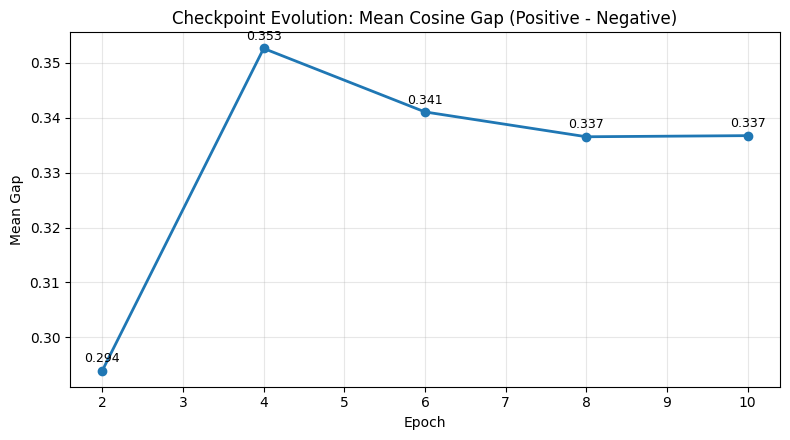

In [8]:
# Plot mean gap (mean_positive - mean_negative) across checkpoints.

import matplotlib.pyplot as plt

if 'multi_ckpt_metrics_df' not in globals() or multi_ckpt_metrics_df.empty:
    raise RuntimeError('multi_ckpt_metrics_df not found or empty. Run the multi-checkpoint evaluation cell first.')

plot_df = multi_ckpt_metrics_df.sort_values('epoch').copy()

plt.figure(figsize=(8, 4.5))
plt.plot(
    plot_df['epoch'],
    plot_df['mean_gap_pos_minus_neg'],
    marker='o',
    linewidth=2,
)

for _, r in plot_df.iterrows():
    plt.annotate(f"{r['mean_gap_pos_minus_neg']:.3f}", (r['epoch'], r['mean_gap_pos_minus_neg']), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=9)

plt.title('Checkpoint Evolution: Mean Cosine Gap (Positive - Negative)')
plt.xlabel('Epoch')
plt.ylabel('Mean Gap')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Retrieval Evaluation Framework

For `retrieval_eval_df`, each datapoint has:
- one **query** story,
- five candidate **options**,
- exactly one positive option.

Evaluation procedure:
1. Embed the query story and all 5 options.
2. Compute cosine similarity between the query embedding and each option embedding.
3. Pick the option with the **highest cosine similarity**.
4. Count a hit if the picked option is the positive option.

Primary metric:
- **Retrieval Accuracy** = `# correct picks / # datapoints`


In [12]:
# Multi-checkpoint retrieval accuracy evaluation on retrieval_eval_df.

import re
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel

RETRIEVAL_EVAL_PATH = PROJECT_ROOT / 'data' / 'eval_data' / 'retrieval_eval_df.csv'
CHECKPOINTS_ROOT = Path('/scratch/shayan/Projects/NarrativeSimilarity/artifacts/e5_mistral_structural_finetune/checkpoints')

if not RETRIEVAL_EVAL_PATH.exists():
    raise FileNotFoundError(f'retrieval eval file not found: {RETRIEVAL_EVAL_PATH}')
if not CHECKPOINTS_ROOT.exists():
    raise FileNotFoundError(f'checkpoint root not found: {CHECKPOINTS_ROOT}')

retrieval_df = pd.read_csv(RETRIEVAL_EVAL_PATH)
required_cols = ['query_text', 'correct_option_index'] + [f'option_{i}_text' for i in range(5)]
missing = [c for c in required_cols if c not in retrieval_df.columns]
if missing:
    raise ValueError(f'Missing required columns in retrieval_eval_df: {missing}')

ckpt_dirs = []
for d in CHECKPOINTS_ROOT.iterdir():
    if d.is_dir() and re.fullmatch(r'epoch_\d+', d.name):
        ckpt_dirs.append(d)
if not ckpt_dirs:
    raise ValueError(f'No epoch_* folders found under: {CHECKPOINTS_ROOT}')
ckpt_dirs = sorted(ckpt_dirs, key=lambda x: int(x.name.split('_')[-1]))

print('Retrieval rows:', len(retrieval_df))
print('Checkpoints:')
for d in ckpt_dirs:
    print(' -', d.name)

if 'DEVICE' not in globals():
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if 'CONFIG' not in globals():
    raise RuntimeError('CONFIG not found. Run config cell first.')

DTYPE_MULTI = torch.bfloat16 if (CONFIG.get('use_bfloat16', False) and DEVICE == 'cuda') else torch.float32


def _mean_pool(last_hidden_state: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    mask = attention_mask.unsqueeze(-1).to(last_hidden_state.dtype)
    summed = (last_hidden_state * mask).sum(dim=1)
    denom = mask.sum(dim=1).clamp(min=1e-9)
    return summed / denom


@torch.no_grad()
def _embed_texts(model, tokenizer, texts, batch_size=8, max_length=1024):
    out = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt',
        )
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        h = model(**enc).last_hidden_state
        pooled = _mean_pool(h, enc['attention_mask'])
        pooled = F.normalize(pooled, p=2, dim=1)
        out.append(pooled.detach().float().cpu())
    return torch.cat(out, dim=0)


def _to_query_text(story: str) -> str:
    return f'query: retrieve stories with a similar narrative to the given story. {story}'


retrieval_ckpt_rows = []

for ckpt in ckpt_dirs:
    epoch_num = int(ckpt.name.split('_')[-1])
    print(f"\nEvaluating retrieval accuracy for {ckpt.name} ...")

    tokenizer_m = AutoTokenizer.from_pretrained(
        str(ckpt),
        trust_remote_code=True,
        cache_dir=str(CONFIG['hf_cache_dir']),
    )
    model_m = AutoModel.from_pretrained(
        str(ckpt),
        trust_remote_code=True,
        cache_dir=str(CONFIG['hf_cache_dir']),
        dtype=DTYPE_MULTI,
    )
    model_m.to(DEVICE)
    model_m.eval()

    correct = 0
    n = len(retrieval_df)

    for _, r in retrieval_df.iterrows():
        q_text = _to_query_text(str(r['query_text']))
        opt_texts = [_to_query_text(str(r[f'option_{i}_text'])) for i in range(5)]

        emb_q = _embed_texts(model_m, tokenizer_m, [q_text], batch_size=1, max_length=CONFIG['max_length'])
        emb_opts = _embed_texts(model_m, tokenizer_m, opt_texts, batch_size=5, max_length=CONFIG['max_length'])

        sims = (emb_opts @ emb_q.squeeze(0)).numpy()  # shape (5,)
        pred_idx = int(np.argmax(sims))
        true_idx = int(r['correct_option_index'])

        if pred_idx == true_idx:
            correct += 1

    acc = correct / n if n > 0 else 0.0

    retrieval_ckpt_rows.append({
        'checkpoint': ckpt.name,
        'epoch': epoch_num,
        'num_queries': int(n),
        'num_correct': int(correct),
        'retrieval_accuracy': float(acc),
    })

    del model_m, tokenizer_m
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

retrieval_ckpt_metrics_df = pd.DataFrame(retrieval_ckpt_rows).sort_values('epoch').reset_index(drop=True)
print('\nRetrieval checkpoint metrics:')
print(retrieval_ckpt_metrics_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

# Save
out_dir = PROJECT_ROOT / 'data' / 'eval_results'
out_dir.mkdir(parents=True, exist_ok=True)
out_csv = out_dir / 'embedding_retrieval_multi_checkpoint_metrics.csv'
retrieval_ckpt_metrics_df.to_csv(out_csv, index=False)
print('\nSaved:', out_csv)


Retrieval rows: 200
Checkpoints:
 - epoch_02
 - epoch_04
 - epoch_06
 - epoch_08
 - epoch_10

Evaluating retrieval accuracy for epoch_02 ...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.58it/s]



Evaluating retrieval accuracy for epoch_04 ...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.58it/s]



Evaluating retrieval accuracy for epoch_06 ...


...


Evaluating retrieval accuracy for epoch_08 ...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.65it/s]



Evaluating retrieval accuracy for epoch_10 ...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.59it/s]



Retrieval checkpoint metrics:
checkpoint  epoch  num_queries  num_correct  retrieval_accuracy
  epoch_02      2          200          189            0.945000
  epoch_04      4          200          190            0.950000
  epoch_06      6          200          189            0.945000
  epoch_08      8          200          190            0.950000
  epoch_10     10          200          190            0.950000

Saved: /tank/scratch/shayan/Projects/NarrativeSimilarity/data/eval_results/embedding_retrieval_multi_checkpoint_metrics.csv


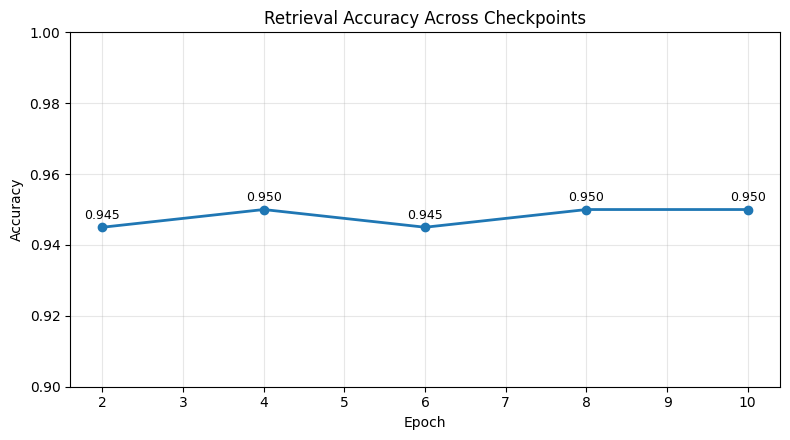

In [15]:
# Plot retrieval accuracy by checkpoint epoch.

import matplotlib.pyplot as plt

if 'retrieval_ckpt_metrics_df' not in globals() or retrieval_ckpt_metrics_df.empty:
    raise RuntimeError('retrieval_ckpt_metrics_df is missing or empty. Run the retrieval multi-checkpoint cell first.')

plot_df = retrieval_ckpt_metrics_df.sort_values('epoch').copy()

plt.figure(figsize=(8, 4.5))
plt.plot(
    plot_df['epoch'],
    plot_df['retrieval_accuracy'],
    marker='o',
    linewidth=2,
)

for _, r in plot_df.iterrows():
    plt.annotate(f"{r['retrieval_accuracy']:.3f}", (r['epoch'], r['retrieval_accuracy']), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=9)

plt.title('Retrieval Accuracy Across Checkpoints')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0.9, 1.0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Mean Cosine Gap for MSE-Loss Checkpoints

Before retrieval evaluation of the MSE-loss checkpoints, compute the mean cosine gap between positive and negative story pairs for each checkpoint.
This provides a complementary checkpoint quality signal to retrieval accuracy.


In [24]:
# Compute mean cosine gap for each MSE checkpoint on the eval pair set.
import re
from pathlib import Path
import torch
import torch.nn.functional as F
import pandas as pd
from transformers import AutoTokenizer, AutoModel

if "eval_df" not in globals():
    raise RuntimeError("eval_df not found. Run the earlier pair evaluation cells first.")

CHECKPOINTS_ROOT_MSE = PROJECT_ROOT / "artifacts" / "e5_mistral_structural_finetune" / "checkpoints_mse_loss"
DTYPE_MULTI = torch.bfloat16 if (CONFIG.get("use_bfloat16", False) and DEVICE == "cuda") else torch.float32
out_dir = PROJECT_ROOT / "data" / "eval_results"
out_dir.mkdir(parents=True, exist_ok=True)

if not CHECKPOINTS_ROOT_MSE.exists():
    raise FileNotFoundError(f"MSE checkpoint root not found: {CHECKPOINTS_ROOT_MSE}")


def _mean_pool(last_hidden_state: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    mask = attention_mask.unsqueeze(-1).to(last_hidden_state.dtype)
    summed = (last_hidden_state * mask).sum(dim=1)
    denom = mask.sum(dim=1).clamp(min=1e-9)
    return summed / denom


@torch.no_grad()
def _embed_texts(model, tokenizer, texts, batch_size=8, max_length=1024):
    outputs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt',
        )
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        out = model(**enc)
        pooled = _mean_pool(out.last_hidden_state, enc['attention_mask'])
        pooled = F.normalize(pooled, p=2, dim=1)
        outputs.append(pooled.detach().float().cpu())
    return torch.cat(outputs, dim=0)

mse_gap_rows = []
for ckpt in sorted(CHECKPOINTS_ROOT_MSE.iterdir(), key=lambda x: int(x.name.split("_")[1])):
    if not ckpt.is_dir() or not re.fullmatch(r"epoch_\d+_mse_loss", ckpt.name):
        continue

    epoch_num = int(ckpt.name.split("_")[1])
    print(f"Evaluating mean cosine gap for {ckpt.name}...")

    tokenizer_m = AutoTokenizer.from_pretrained(
        str(ckpt),
        trust_remote_code=True,
        cache_dir=str(CONFIG["hf_cache_dir"]),
    )
    model_m = AutoModel.from_pretrained(
        str(ckpt),
        trust_remote_code=True,
        cache_dir=str(CONFIG["hf_cache_dir"]),
        dtype=DTYPE_MULTI,
    )
    model_m.to(DEVICE)
    model_m.eval()

    texts_a = [f"query: retrieve stories with a similar narrative to the given story. {str(x)}" for x in eval_df["story_text_a"]]
    texts_b = [f"query: retrieve stories with a similar narrative to the given story. {str(x)}" for x in eval_df["story_text_b"]]
    emb_a = _embed_texts(model_m, tokenizer_m, texts_a, batch_size=8, max_length=CONFIG["max_length"])
    emb_b = _embed_texts(model_m, tokenizer_m, texts_b, batch_size=8, max_length=CONFIG["max_length"])

    cos_scores = (emb_a * emb_b).sum(dim=1).numpy()
    tmp = eval_df[["label"]].copy()
    tmp["cosine_similarity"] = cos_scores

    stats = tmp.groupby("label")["cosine_similarity"].agg(["mean"])
    mean_neg = float(stats.loc[0, "mean"])
    mean_pos = float(stats.loc[1, "mean"])
    mean_gap = mean_pos - mean_neg

    mse_gap_rows.append({
        "checkpoint": ckpt.name,
        "epoch": epoch_num,
        "mean_negative": mean_neg,
        "mean_positive": mean_pos,
        "mean_gap_pos_minus_neg": mean_gap,
    })

    del model_m, tokenizer_m
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

mse_gap_df = pd.DataFrame(mse_gap_rows).sort_values("epoch").reset_index(drop=True)
print("MSE checkpoint mean cosine gap:")
print(mse_gap_df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

gap_out_csv = out_dir / "embedding_eval_mse_checkpoint_mean_gap.csv"
mse_gap_df.to_csv(gap_out_csv, index=False)
print("Saved:", gap_out_csv)


Evaluating mean cosine gap for epoch_02_mse_loss...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.20it/s]


Evaluating mean cosine gap for epoch_04_mse_loss...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.62it/s]


Evaluating mean cosine gap for epoch_06_mse_loss...


...

Evaluating mean cosine gap for epoch_08_mse_loss...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.67it/s]
Loading adapter weights from /tank/scratch/shayan/Projects/NarrativeSimilarity/artifacts/e5_mistral_structural_finetune/checkpoints_mse_loss/epoch_08_mse_loss led to unexpected keys not found in the model: base_model.model.layers.0.mlp.down_proj.lora_A.default.weight, base_model.model.layers.0.mlp.down_proj.lora_B.default.weight, base_model.model.layers.0.mlp.gate_proj.lora_A.default.weight, base_model.model.layers.0.mlp.gate_proj.lora_B.default.weight, base_model.model.layers.0.mlp.up_proj.lora_A.default.weight, base_model.model.layers.0.mlp.up_proj.lora_B.default.weight, base_model.model.layers.0.self_attn.k_proj.lora_A.default.weight, base_model.model.layers.0.self_attn.k_proj.lora_B.default.weight, base_model.model.layers.0.self_attn.o_proj.lora_A.default.weight, base_model.model.layers.0.self_attn.o_proj.lora_B.default.weight, base_model.model.layers.0.self_attn.q_proj.lora_A.default.weight, base_model.model.

Evaluating mean cosine gap for epoch_10_mse_loss...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.61it/s]
Loading adapter weights from /tank/scratch/shayan/Projects/NarrativeSimilarity/artifacts/e5_mistral_structural_finetune/checkpoints_mse_loss/epoch_10_mse_loss led to unexpected keys not found in the model: base_model.model.layers.0.mlp.down_proj.lora_A.default.weight, base_model.model.layers.0.mlp.down_proj.lora_B.default.weight, base_model.model.layers.0.mlp.gate_proj.lora_A.default.weight, base_model.model.layers.0.mlp.gate_proj.lora_B.default.weight, base_model.model.layers.0.mlp.up_proj.lora_A.default.weight, base_model.model.layers.0.mlp.up_proj.lora_B.default.weight, base_model.model.layers.0.self_attn.k_proj.lora_A.default.weight, base_model.model.layers.0.self_attn.k_proj.lora_B.default.weight, base_model.model.layers.0.self_attn.o_proj.lora_A.default.weight, base_model.model.layers.0.self_attn.o_proj.lora_B.default.weight, base_model.model.layers.0.self_attn.q_proj.lora_A.default.weight, base_model.model.

MSE checkpoint mean cosine gap:
       checkpoint  epoch  mean_negative  mean_positive  mean_gap_pos_minus_neg
epoch_02_mse_loss      2       0.268434       0.721128                0.452694
epoch_04_mse_loss      4       0.291407       0.749716                0.458309
epoch_06_mse_loss      6       0.728903       0.891242                0.162338
epoch_08_mse_loss      8       0.728903       0.891242                0.162338
epoch_10_mse_loss     10       0.728903       0.891242                0.162338
Saved: /tank/scratch/shayan/Projects/NarrativeSimilarity/data/eval_results/embedding_eval_mse_checkpoint_mean_gap.csv


In [6]:
# Multi-checkpoint retrieval accuracy evaluation on MSE-loss checkpoints.

import re
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel

RETRIEVAL_EVAL_PATH = PROJECT_ROOT / 'data' / 'eval_data' / 'retrieval_eval_df.csv'
CHECKPOINTS_ROOT_MSE = PROJECT_ROOT / 'artifacts' / 'e5_mistral_structural_finetune' / 'checkpoints_mse_loss'

if not RETRIEVAL_EVAL_PATH.exists():
    raise FileNotFoundError(f'retrieval eval file not found: {RETRIEVAL_EVAL_PATH}')
if not CHECKPOINTS_ROOT_MSE.exists():
    raise FileNotFoundError(f'MSE checkpoint root not found: {CHECKPOINTS_ROOT_MSE}')

retrieval_df = pd.read_csv(RETRIEVAL_EVAL_PATH)
required_cols = ['query_text', 'correct_option_index'] + [f'option_{i}_text' for i in range(5)]
missing = [c for c in required_cols if c not in retrieval_df.columns]
if missing:
    raise ValueError(f'Missing required columns in retrieval_eval_df: {missing}')

# Checkpoint folder names: epoch_02_mse_loss, epoch_04_mse_loss, ...
ckpt_dirs = []
for d in CHECKPOINTS_ROOT_MSE.iterdir():
    if d.is_dir() and re.fullmatch(r'epoch_\d+_mse_loss', d.name):
        ckpt_dirs.append(d)
if not ckpt_dirs:
    raise ValueError(f'No epoch_*_mse_loss folders found under: {CHECKPOINTS_ROOT_MSE}')
ckpt_dirs = sorted(ckpt_dirs, key=lambda x: int(x.name.split('_')[1]))

print('Retrieval rows:', len(retrieval_df))
print('MSE checkpoints:')
for d in ckpt_dirs:
    print(' -', d.name)

if 'DEVICE' not in globals():
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if 'CONFIG' not in globals():
    raise RuntimeError('CONFIG not found. Run config cell first.')

DTYPE_MULTI = torch.bfloat16 if (CONFIG.get('use_bfloat16', False) and DEVICE == 'cuda') else torch.float32


def _mean_pool(last_hidden_state: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    mask = attention_mask.unsqueeze(-1).to(last_hidden_state.dtype)
    summed = (last_hidden_state * mask).sum(dim=1)
    denom = mask.sum(dim=1).clamp(min=1e-9)
    return summed / denom


@torch.no_grad()
def _embed_texts(model, tokenizer, texts, batch_size=8, max_length=1024):
    out = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt',
        )
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        h = model(**enc).last_hidden_state
        pooled = _mean_pool(h, enc['attention_mask'])
        pooled = F.normalize(pooled, p=2, dim=1)
        out.append(pooled.detach().float().cpu())
    return torch.cat(out, dim=0)


def _to_query_text(story: str) -> str:
    return f'query: retrieve stories with a similar narrative to the given story. {story}'


retrieval_ckpt_rows_mse = []

for ckpt in ckpt_dirs:
    epoch_num = int(ckpt.name.split('_')[1])
    print(f"\nEvaluating retrieval accuracy for {ckpt.name} ...")

    tokenizer_m = AutoTokenizer.from_pretrained(
        str(ckpt),
        trust_remote_code=True,
        cache_dir=str(CONFIG['hf_cache_dir']),
    )
    model_m = AutoModel.from_pretrained(
        str(ckpt),
        trust_remote_code=True,
        cache_dir=str(CONFIG['hf_cache_dir']),
        dtype=DTYPE_MULTI,
    )
    model_m.to(DEVICE)
    model_m.eval()

    correct = 0
    n = len(retrieval_df)

    for _, r in retrieval_df.iterrows():
        q_text = _to_query_text(str(r['query_text']))
        opt_texts = [_to_query_text(str(r[f'option_{i}_text'])) for i in range(5)]

        emb_q = _embed_texts(model_m, tokenizer_m, [q_text], batch_size=1, max_length=CONFIG['max_length'])
        emb_opts = _embed_texts(model_m, tokenizer_m, opt_texts, batch_size=5, max_length=CONFIG['max_length'])

        sims = (emb_opts @ emb_q.squeeze(0)).numpy()
        pred_idx = int(np.argmax(sims))
        true_idx = int(r['correct_option_index'])

        if pred_idx == true_idx:
            correct += 1

    acc = correct / n if n > 0 else 0.0

    retrieval_ckpt_rows_mse.append({
        'checkpoint': ckpt.name,
        'epoch': epoch_num,
        'num_queries': int(n),
        'num_correct': int(correct),
        'retrieval_accuracy': float(acc),
    })

    del model_m, tokenizer_m
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

retrieval_ckpt_metrics_mse_df = pd.DataFrame(retrieval_ckpt_rows_mse).sort_values('epoch').reset_index(drop=True)
print('\nMSE retrieval checkpoint metrics:')
print(retrieval_ckpt_metrics_mse_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

# Save
out_dir = PROJECT_ROOT / 'data' / 'eval_results'
out_dir.mkdir(parents=True, exist_ok=True)
out_csv = out_dir / 'embedding_retrieval_multi_checkpoint_metrics_mse_loss.csv'
retrieval_ckpt_metrics_mse_df.to_csv(out_csv, index=False)
print('\nSaved:', out_csv)


Retrieval rows: 200
MSE checkpoints:
 - epoch_02_mse_loss
 - epoch_04_mse_loss
 - epoch_06_mse_loss
 - epoch_08_mse_loss
 - epoch_10_mse_loss

Evaluating retrieval accuracy for epoch_02_mse_loss ...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.62it/s]



Evaluating retrieval accuracy for epoch_04_mse_loss ...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.62it/s]



Evaluating retrieval accuracy for epoch_06_mse_loss ...


...


Evaluating retrieval accuracy for epoch_08_mse_loss ...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.59it/s]
Loading adapter weights from /tank/scratch/shayan/Projects/NarrativeSimilarity/artifacts/e5_mistral_structural_finetune/checkpoints_mse_loss/epoch_08_mse_loss led to unexpected keys not found in the model: base_model.model.layers.0.mlp.down_proj.lora_A.default.weight, base_model.model.layers.0.mlp.down_proj.lora_B.default.weight, base_model.model.layers.0.mlp.gate_proj.lora_A.default.weight, base_model.model.layers.0.mlp.gate_proj.lora_B.default.weight, base_model.model.layers.0.mlp.up_proj.lora_A.default.weight, base_model.model.layers.0.mlp.up_proj.lora_B.default.weight, base_model.model.layers.0.self_attn.k_proj.lora_A.default.weight, base_model.model.layers.0.self_attn.k_proj.lora_B.default.weight, base_model.model.layers.0.self_attn.o_proj.lora_A.default.weight, base_model.model.layers.0.self_attn.o_proj.lora_B.default.weight, base_model.model.layers.0.self_attn.q_proj.lora_A.default.weight, base_model.model.


Evaluating retrieval accuracy for epoch_10_mse_loss ...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.62it/s]
Loading adapter weights from /tank/scratch/shayan/Projects/NarrativeSimilarity/artifacts/e5_mistral_structural_finetune/checkpoints_mse_loss/epoch_10_mse_loss led to unexpected keys not found in the model: base_model.model.layers.0.mlp.down_proj.lora_A.default.weight, base_model.model.layers.0.mlp.down_proj.lora_B.default.weight, base_model.model.layers.0.mlp.gate_proj.lora_A.default.weight, base_model.model.layers.0.mlp.gate_proj.lora_B.default.weight, base_model.model.layers.0.mlp.up_proj.lora_A.default.weight, base_model.model.layers.0.mlp.up_proj.lora_B.default.weight, base_model.model.layers.0.self_attn.k_proj.lora_A.default.weight, base_model.model.layers.0.self_attn.k_proj.lora_B.default.weight, base_model.model.layers.0.self_attn.o_proj.lora_A.default.weight, base_model.model.layers.0.self_attn.o_proj.lora_B.default.weight, base_model.model.layers.0.self_attn.q_proj.lora_A.default.weight, base_model.model.


MSE retrieval checkpoint metrics:
       checkpoint  epoch  num_queries  num_correct  retrieval_accuracy
epoch_02_mse_loss      2          200          194            0.970000
epoch_04_mse_loss      4          200          180            0.900000
epoch_06_mse_loss      6          200          194            0.970000
epoch_08_mse_loss      8          200          194            0.970000
epoch_10_mse_loss     10          200          194            0.970000

Saved: /tank/scratch/shayan/Projects/NarrativeSimilarity/data/eval_results/embedding_retrieval_multi_checkpoint_metrics_mse_loss.csv


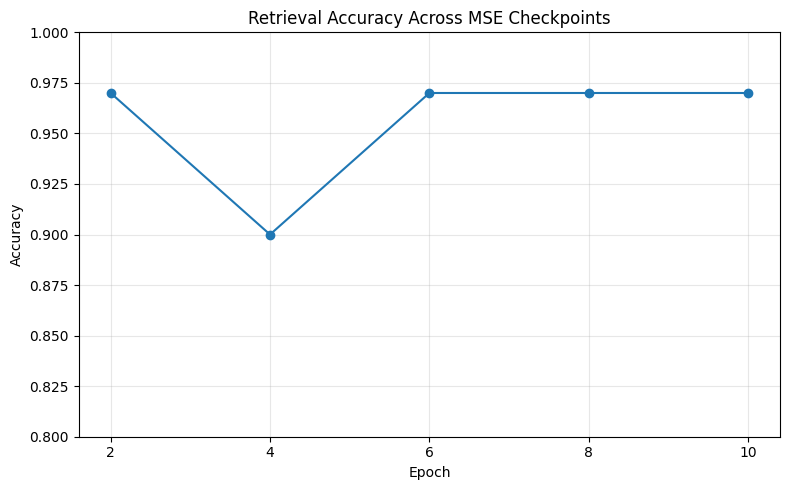

       checkpoint  epoch  retrieval_accuracy
epoch_02_mse_loss      2            0.970000
epoch_04_mse_loss      4            0.900000
epoch_06_mse_loss      6            0.970000
epoch_08_mse_loss      8            0.970000
epoch_10_mse_loss     10            0.970000


In [7]:
# Plot retrieval accuracy over MSE-loss checkpoints.

import matplotlib.pyplot as plt

if 'retrieval_ckpt_metrics_mse_df' not in globals():
    raise RuntimeError('retrieval_ckpt_metrics_mse_df not found. Run the MSE retrieval multi-checkpoint eval cell first.')

plot_df = retrieval_ckpt_metrics_mse_df.sort_values('epoch').reset_index(drop=True)

plt.figure(figsize=(8, 5))
plt.plot(plot_df['epoch'], plot_df['retrieval_accuracy'], marker='o')
plt.title('Retrieval Accuracy Across MSE Checkpoints')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(plot_df['epoch'].tolist())
plt.ylim(0.8, 1.0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(plot_df[['checkpoint', 'epoch', 'retrieval_accuracy']].to_string(index=False, float_format=lambda x: f'{x:.6f}'))

## Compare embedding accuracy with an LLM

We want to compare embedding-based evaluation performance against an LLM (GPT-5) on the same tasks evaluated earlier in this notebook.

This comparison will:
- read the OpenAI API key from `openai_key.txt`
- evaluate the same story pair similarity task used for the embeddings
- evaluate the retrieval task when `retrieval_df` is available
- print GPT-5 performance metrics for direct comparison

In [12]:
import importlib.util
import re
from tqdm import tqdm

if importlib.util.find_spec('openai') is None:
    raise ImportError(
        'The openai Python package is not installed. Install it with `pip install openai` and restart the kernel.'
    )

import openai

openai_key_path = PROJECT_ROOT / 'openai_key.txt'
if not openai_key_path.exists():
    raise FileNotFoundError(f'OpenAI key file not found: {openai_key_path}')
with open(openai_key_path, 'r', encoding='utf-8') as f:
    api_key = f.read().strip()

# Create client for new API, fallback to global for old API
try:
    client = openai.OpenAI(api_key=api_key)
    use_client = True
except AttributeError:
    openai.api_key = api_key
    client = None
    use_client = False

MODEL_NAME = 'gpt-4'
FALLBACK_MODELS = ['gpt-4-turbo', 'gpt-3.5-turbo']


RETRIEVAL_EVAL_PATH = PROJECT_ROOT / 'data' / 'eval_data' / 'retrieval_eval_df.csv'
CHECKPOINTS_ROOT = Path('/scratch/shayan/Projects/NarrativeSimilarity/artifacts/e5_mistral_structural_finetune/checkpoints')

if not RETRIEVAL_EVAL_PATH.exists():
    raise FileNotFoundError(f'retrieval eval file not found: {RETRIEVAL_EVAL_PATH}')
if not CHECKPOINTS_ROOT.exists():
    raise FileNotFoundError(f'checkpoint root not found: {CHECKPOINTS_ROOT}')

retrieval_df = pd.read_csv(RETRIEVAL_EVAL_PATH)


def _openai_create(messages, max_tokens=10, temperature=0.0):
    last_exc = None
    for model_name in [MODEL_NAME] + FALLBACK_MODELS:
        try:
            if use_client and client:
                return client.chat.completions.create(
                    model=model_name,
                    messages=messages,
                    max_tokens=max_tokens,
                    temperature=temperature,
                )
            else:
                return openai.ChatCompletion.create(
                    model=model_name,
                    messages=messages,
                    max_tokens=max_tokens,
                    temperature=temperature,
                )
        except Exception as exc:
            last_exc = exc
            print(f'OpenAI model {model_name} failed: {exc}')
            continue
    raise RuntimeError('All OpenAI model calls failed.') from last_exc


def _parse_openai_text(response):
    if isinstance(response, dict):
        if response.get('choices'):
            choice = response['choices'][0]
            message = choice.get('message', {})
            return message.get('content', '')
        return response.get('output_text', '') or response.get('output', [{}])[0].get('content', '')

    if hasattr(response, 'choices') and response.choices:
        choice = response.choices[0]
        if hasattr(choice, 'message') and hasattr(choice.message, 'content'):
            return choice.message.content.strip()
        if hasattr(choice, 'message'):
            return choice.message['content'].strip()
        return choice['message']['content'].strip()

    if hasattr(response, 'output_text'):
        return response.output_text.strip()

    if hasattr(response, 'output'):
        output = response.output
        if isinstance(output, list) and output:
            item = output[0]
            if isinstance(item, dict):
                return item.get('content', '')
            return str(item)
    raise ValueError('Cannot parse OpenAI response content.')


def _llm_score_pair(story_a: str, story_b: str) -> float:
    prompt = (
        'Rate the narrative structural similarity between the two stories below on a scale from 0 to 1.'
        '\n\nStory A:\n'
        f'{story_a}\n\n'
        'Story B:\n'
        f'{story_b}\n\n'
        'Answer with only a single numeric score between 0 and 1.'
    )
    response = _openai_create(
        messages=[
            {'role': 'system', 'content': 'You are a helpful assistant that rates narrative story similarity.'},
            {'role': 'user', 'content': prompt},
        ],
        max_tokens=10,
        temperature=0.0,
    )
    text = _parse_openai_text(response)
    match = re.search(r'[-+]?[0-9]*\.?[0-9]+(?:[eE][-+]?[0-9]+)?', text)
    if not match:
        raise ValueError(f'Unexpected LLM output for similarity score: {text}')
    value = float(match.group(0))
    return max(0.0, min(1.0, value))


def _evaluate_llm_pair_accuracy(df: pd.DataFrame, threshold: float = 0.5) -> dict:
    scores = []
    labels = df['label'].tolist()
    for story_a, story_b in tqdm(zip(df['story_text_a'], df['story_text_b']), desc="Evaluating pairs", total=len(df)):
        scores.append(_llm_score_pair(str(story_a), str(story_b)))

    pred_labels = [1 if s >= threshold else 0 for s in scores]
    return {
        'accuracy': accuracy_score(labels, pred_labels),
        'f1': f1_score(labels, pred_labels),
        'roc_auc': roc_auc_score(labels, scores),
        'average_precision': average_precision_score(labels, scores),
    }


def _llm_retrieval_accuracy(df: pd.DataFrame) -> float:
    correct = 0
    for _, row in tqdm(df.iterrows(), desc="Evaluating retrieval", total=len(df)):
        query_text = row['query_text']
        option_texts = [row[f'option_{i}_text'] for i in range(5)]
        prompt = (
            'Given the query below, choose the most structurally similar story from the five options.\n\n'
            'Query:\n'
            f'{query_text}\n\n'
            'Options:\n'
        )
        for idx, option in enumerate(option_texts, start=1):
            prompt += f'{idx}. {option}\n'
        prompt += '\nAnswer with the number of the best matching option.'

        response = _openai_create(
            messages=[
                {'role': 'system', 'content': 'You are a helpful assistant that selects the most structurally similar story.'},
                {'role': 'user', 'content': prompt},
            ],
            max_tokens=10,
            temperature=0.0,
        )
        text = _parse_openai_text(response)
        match = re.search(r'\b([1-5])\b', text)
        if not match:
            raise ValueError(f'Unexpected LLM retrieval output: {text}')
        pred_idx = int(match.group(1)) - 1
        if pred_idx == int(row['correct_option_index']):
            correct += 1
    return correct / len(df)

print('Evaluating GPT-5.4 on eval pairs...')
pair_metrics = _evaluate_llm_pair_accuracy(eval_df)
print('LLM pair evaluation metrics:')
for metric, value in pair_metrics.items():
    print(f'  {metric}: {value:.4f}')

if 'retrieval_df' in globals():
    print('\nEvaluating GPT-5.4 on retrieval tasks...')
    retrieval_accuracy = _llm_retrieval_accuracy(retrieval_df)
    print(f'LLM retrieval accuracy: {retrieval_accuracy:.4f}')
else:
    print('retrieval_df not found in globals; run the retrieval evaluation section first before comparing GPT-5.4.')

Evaluating GPT-5.4 on eval pairs...


Evaluating pairs: 100%|██████████| 200/200 [03:23<00:00,  1.02s/it]


LLM pair evaluation metrics:
  accuracy: 0.9950
  f1: 0.9950
  roc_auc: 1.0000
  average_precision: 1.0000

Evaluating GPT-5.4 on retrieval tasks...


Evaluating retrieval: 100%|██████████| 200/200 [03:43<00:00,  1.12s/it]

LLM retrieval accuracy: 0.9750


## Synthetic Anchor Ranking Evaluation (MSE Epoch 02)

This evaluation uses the synthetic theme dataset where each theme has `story_1`, `story_2`, and `story_3`. 
`story_1` is the anchor. 

For each row, we compute cosine similarities `(story_1, story_2)` and `(story_1, story_3)` using the MSE fine-tuned checkpoint at epoch 02. 

The prediction is whichever of `story_2` or `story_3` is more similar to `story_1`. Ground truth comes from structural labels: compare `struct_score_12` vs `struct_score_13` (derived from `pred_event_rating_mean_joint`). 

Metric: accuracy = number of correct rankings / number of non-tie rows.


In [3]:
# Evaluate MSE epoch_02 by anchor ranking on synthetic_anchor_eval_data.
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel

ANCHOR_EVAL_PATH = PROJECT_ROOT / 'data' / 'eval_data' / 'synthetic_anchor_eval_data.csv'
MSE_CKPT = PROJECT_ROOT / 'artifacts' / 'e5_mistral_structural_finetune' / 'checkpoints_mse_loss' / 'epoch_02_mse_loss'

if not ANCHOR_EVAL_PATH.exists():
    raise FileNotFoundError(f"Missing eval file: {ANCHOR_EVAL_PATH}")
if not MSE_CKPT.exists():
    raise FileNotFoundError(f"Missing checkpoint: {MSE_CKPT}")

anchor_df = pd.read_csv(ANCHOR_EVAL_PATH)
required = ['story_1', 'story_2', 'story_3', 'struct_score_12', 'struct_score_13']
missing = [c for c in required if c not in anchor_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

DEVICE_LOCAL = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE_LOCAL = torch.bfloat16 if (DEVICE_LOCAL == 'cuda' and CONFIG.get('use_bfloat16', False)) else torch.float32

tokenizer = AutoTokenizer.from_pretrained(str(MSE_CKPT), trust_remote_code=True, cache_dir=str(CONFIG["hf_cache_dir"]))
model = AutoModel.from_pretrained(str(MSE_CKPT), trust_remote_code=True, cache_dir=str(CONFIG["hf_cache_dir"]), dtype=DTYPE_LOCAL)
model.to(DEVICE_LOCAL)
model.eval()

def _mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).to(last_hidden_state.dtype)
    summed = (last_hidden_state * mask).sum(dim=1)
    denom = mask.sum(dim=1).clamp(min=1e-9)
    return summed / denom

@torch.no_grad()
def _embed(texts, max_length=1024, batch_size=8):
    out = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt")
        enc = {k: v.to(DEVICE_LOCAL) for k, v in enc.items()}
        h = model(**enc).last_hidden_state
        pooled = _mean_pool(h, enc["attention_mask"])
        pooled = F.normalize(pooled, p=2, dim=1)
        out.append(pooled.float().cpu())
    return torch.cat(out, dim=0)

def _to_query_text(story):
    return f"query: retrieve stories with a similar narrative to the given story. {story}"

valid_rows = []
for _, r in anchor_df.iterrows():
    s12 = float(r["struct_score_12"])
    s13 = float(r["struct_score_13"])
    if s12 == s13:
        continue
    gt = 'story_2' if s12 > s13 else 'story_3'
    valid_rows.append((r, gt))

correct = 0
rows_out = []
for r, gt in valid_rows:
    t1 = _to_query_text(str(r["story_1"]))
    t2 = _to_query_text(str(r["story_2"]))
    t3 = _to_query_text(str(r["story_3"]))

    embs = _embed([t1, t2, t3], max_length=CONFIG["max_length"], batch_size=3)
    e1, e2, e3 = embs[0], embs[1], embs[2]
    cos_12 = float(torch.dot(e1, e2).item())
    cos_13 = float(torch.dot(e1, e3).item())
    pred = 'story_2' if cos_12 > cos_13 else 'story_3'
    is_correct = (pred == gt)
    correct += int(is_correct)

    rows_out.append({
        'theme': r.get('theme', ''),
        'gt_higher_vs_story_1': gt,
        'pred_higher_vs_story_1': pred,
        'cos_12': cos_12,
        'cos_13': cos_13,
        'struct_score_12': float(r['struct_score_12']),
        'struct_score_13': float(r['struct_score_13']),
        'correct': is_correct,
    })

n = len(valid_rows)
acc = (correct / n) if n > 0 else 0.0
pred_df = pd.DataFrame(rows_out)

print(f"Checkpoint: {MSE_CKPT}")
print(f"Non-tie rows: {n}")
print(f"Correct: {correct}")
print(f"Accuracy: {acc:.6f}")
display(pred_df.head(10))

OUT_METRIC = PROJECT_ROOT / 'data' / 'eval_results' / 'synthetic_anchor_eval_epoch02_mse_metrics.json'
OUT_PRED = PROJECT_ROOT / 'data' / 'eval_results' / 'synthetic_anchor_eval_epoch02_mse_predictions.csv'
OUT_METRIC.parent.mkdir(parents=True, exist_ok=True)
OUT_METRIC.write_text(json.dumps({
    'checkpoint': str(MSE_CKPT),
    'num_non_tie_rows': int(n),
    'num_correct': int(correct),
    'accuracy': float(acc),
}, indent=2), encoding="utf-8")
pred_df.to_csv(OUT_PRED, index=False)
print("Saved:", OUT_METRIC)
print("Saved:", OUT_PRED)


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.16it/s]


Checkpoint: /tank/scratch/shayan/Projects/NarrativeSimilarity/artifacts/e5_mistral_structural_finetune/checkpoints_mse_loss/epoch_02_mse_loss
Non-tie rows: 20
Correct: 14
Accuracy: 0.700000


,theme,gt_higher_vs_story_1,pred_higher_vs_story_1,cos_12,cos_13,struct_score_12,struct_score_13,correct
0,Starting a new job,story_3,story_3,0.805012,0.881071,2.413691,2.430809,True
1,Recovering after a breakup,story_2,story_3,0.809931,0.856130,2.500864,2.485530,False
2,Training for a marathon,story_3,story_3,0.847943,0.882274,2.480468,2.488248,True
3,Immigrating to a new country,story_3,story_3,0.705703,0.763026,2.399212,2.490237,True
4,Launching a small business,story_3,story_3,0.746069,0.843399,2.358588,2.467124,True
5,Caring for an aging parent,story_3,story_3,0.795665,0.837430,2.411314,2.546768,True
6,Navigating high school friendships,story_3,story_2,0.649022,0.594570,2.464038,2.464799,False
7,Surviving financial hardship,story_2,story_3,0.801925,0.913186,2.507807,2.504027,False
8,Preparing for a major exam,story_3,story_3,0.778607,0.809729,2.511330,2.578381,True
9,Healing after an accident,story_3,story_3,0.687894,0.696345,2.518242,2.526967,True


Saved: /tank/scratch/shayan/Projects/NarrativeSimilarity/data/eval_results/synthetic_anchor_eval_epoch02_mse_metrics.json
Saved: /tank/scratch/shayan/Projects/NarrativeSimilarity/data/eval_results/synthetic_anchor_eval_epoch02_mse_predictions.csv


### Now let's see how an LLM would do this task

In [7]:
# LLM-based anchor ranking eval (gpt-5.4) on synthetic_anchor_eval_data.
import json
import re
import time
from pathlib import Path

import pandas as pd
from tqdm.auto import tqdm
from openai import OpenAI

ANCHOR_EVAL_PATH = PROJECT_ROOT / 'data' / 'eval_data' / 'synthetic_anchor_eval_data.csv'
OUT_METRIC = PROJECT_ROOT / 'data' / 'eval_results' / 'synthetic_anchor_eval_gpt54_metrics.json'
OUT_PRED = PROJECT_ROOT / 'data' / 'eval_results' / 'synthetic_anchor_eval_gpt54_predictions.csv'
MODEL_NAME = 'gpt-5.4'
REQUEST_SLEEP_SECONDS = 0.1

if not ANCHOR_EVAL_PATH.exists():
    raise FileNotFoundError(f"Missing eval file: {ANCHOR_EVAL_PATH}")

key_path = PROJECT_ROOT / "openai_key.txt"
if not key_path.exists():
    key_path = PROJECT_ROOT.parent / "openai_key.txt"
if not key_path.exists():
    raise FileNotFoundError(f"openai_key.txt not found under {PROJECT_ROOT} or parent")
api_key = key_path.read_text(encoding="utf-8").strip()
if not api_key:
    raise ValueError(f"openai_key.txt is empty: {key_path}")

client = OpenAI(api_key=api_key)
anchor_df = pd.read_csv(ANCHOR_EVAL_PATH)

required = ['theme', 'story_1', 'story_2', 'story_3', 'struct_score_12', 'struct_score_13']
missing = [c for c in required if c not in anchor_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

system_prompt = """You are a careful narrative structure evaluator.

Given one anchor story and two candidate stories, choose which candidate is structurally more similar to the anchor.
Focus on narrative progression, major events, and ordering of what happens.
Ignore writing style and surface wording differences.

Return strict JSON only:
{"choice": "story_2"} or {"choice": "story_3"}
"""

def build_user_prompt(r):
    return (
        f"Theme: {r.get('theme', '')}\n\n"
        f"Anchor (story_1):\n{r['story_1']}\n\n"
        f"Candidate A (story_2):\n{r['story_2']}\n\n"
        f"Candidate B (story_3):\n{r['story_3']}\n\n"
        "Which candidate is structurally more similar to the anchor?"
    )

def parse_choice(text):
    t = (text or "").strip()
    try:
        obj = json.loads(t)
        ch = str(obj.get("choice", "")).strip().lower()
        if ch in {"story_2", "story_3"}:
            return ch
    except Exception:
        pass
    m = re.search(r"story_[23]", t.lower())
    if m:
        return m.group(0)
    return None

rows = []
for _, r in anchor_df.iterrows():
    s12 = float(r["struct_score_12"])
    s13 = float(r["struct_score_13"])
    if s12 == s13:
        continue
    gt = 'story_2' if s12 > s13 else 'story_3'
    rows.append((r, gt))

results = []
correct = 0
errors = 0

pbar = tqdm(rows, desc="LLM anchor eval", unit="row")
for r, gt in pbar:
    try:
        resp = client.responses.create(
            model=MODEL_NAME,
            input=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": build_user_prompt(r)},
            ],
        )
        raw = getattr(resp, "output_text", "")
        pred = parse_choice(raw)
        is_correct = (pred == gt)
        correct += int(is_correct)

        results.append({
            "theme": r.get("theme", ""),
            "gt_higher_vs_story_1": gt,
            "pred_higher_vs_story_1": pred,
            "correct": bool(is_correct),
            "struct_score_12": float(r["struct_score_12"]),
            "struct_score_13": float(r["struct_score_13"]),
            "raw_response": raw,
        })
    except Exception as e:
        errors += 1
        results.append({
            "theme": r.get("theme", ""),
            "gt_higher_vs_story_1": gt,
            "pred_higher_vs_story_1": None,
            "correct": False,
            "struct_score_12": float(r["struct_score_12"]),
            "struct_score_13": float(r["struct_score_13"]),
            "error": str(e),
        })

    n_done = len(results)
    acc_so_far = (correct / n_done) if n_done > 0 else 0.0
    pbar.set_postfix(correct=correct, errors=errors, acc=f"{acc_so_far:.3f}")
    time.sleep(REQUEST_SLEEP_SECONDS)

pred_df = pd.DataFrame(results)
n = len(rows)
accuracy = (correct / n) if n > 0 else 0.0

OUT_METRIC.parent.mkdir(parents=True, exist_ok=True)
OUT_PRED.parent.mkdir(parents=True, exist_ok=True)
OUT_METRIC.write_text(json.dumps({
    "model": MODEL_NAME,
    "num_non_tie_rows": int(n),
    "num_correct": int(correct),
    "num_errors": int(errors),
    "accuracy": float(accuracy),
}, indent=2), encoding="utf-8")
pred_df.to_csv(OUT_PRED, index=False)

print(f"Model: {MODEL_NAME}")
print(f"Non-tie rows: {n}")
print(f"Correct: {correct}")
print(f"Errors: {errors}")
print(f"Accuracy: {accuracy:.6f}")
print("Saved:", OUT_METRIC)
print("Saved:", OUT_PRED)
display(pred_df.head(10))


LLM anchor eval: 100%|██████████| 20/20 [00:33<00:00,  1.66s/row, acc=0.750, correct=15, errors=0]

Model: gpt-5.4
Non-tie rows: 20
Correct: 15
Errors: 0
Accuracy: 0.750000
Saved: /tank/scratch/shayan/Projects/NarrativeSimilarity/data/eval_results/synthetic_anchor_eval_gpt54_metrics.json
Saved: /tank/scratch/shayan/Projects/NarrativeSimilarity/data/eval_results/synthetic_anchor_eval_gpt54_predictions.csv


,theme,gt_higher_vs_story_1,pred_higher_vs_story_1,correct,struct_score_12,struct_score_13,raw_response
0,Starting a new job,story_3,story_3,True,2.413691,2.430809,"{""choice"":""story_3""}"
1,Recovering after a breakup,story_2,story_2,True,2.500864,2.485530,"{""choice"":""story_2""}"
2,Training for a marathon,story_3,story_3,True,2.480468,2.488248,"{""choice"":""story_3""}"
3,Immigrating to a new country,story_3,story_3,True,2.399212,2.490237,"{""choice"":""story_3""}"
4,Launching a small business,story_3,story_3,True,2.358588,2.467124,"{""choice"":""story_3""}"
5,Caring for an aging parent,story_3,story_3,True,2.411314,2.546768,"{""choice"":""story_3""}"
6,Navigating high school friendships,story_3,story_3,True,2.464038,2.464799,"{""choice"":""story_3""}"
7,Surviving financial hardship,story_2,story_3,False,2.507807,2.504027,"{""choice"":""story_3""}"
8,Preparing for a major exam,story_3,story_3,True,2.511330,2.578381,"{""choice"":""story_3""}"
9,Healing after an accident,story_3,story_3,True,2.518242,2.526967,"{""choice"":""story_3""}"


## SemEval 2026 Track A: Embedding Evaluation (Epoch 02)

We evaluate the epoch-2 MSE fine-tuned embedding checkpoint on `dev_track_a.jsonl` triplets. 

For each sample, we compute cosine similarity between anchor and `text_a`, and anchor and `text_b`; prediction is whichever is higher.

Ground truth is the binary label indicating whether `text_a` is closer (otherwise `text_b` is closer).


In [7]:
# Evaluate epoch_02 MSE embedding on SemEval2026 Task 4 dev_track_a triplets.
import json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm

SEMEVAL_PATH = PROJECT_ROOT / 'data' / 'eval_data' / 'SemEval2026-Task_4-dev-v1' / 'dev_track_a.jsonl'
MSE_CKPT = PROJECT_ROOT / 'artifacts' / 'e5_mistral_structural_finetune' / 'checkpoints_mse_loss' / 'epoch_02_mse_loss'

if not SEMEVAL_PATH.exists():
    raise FileNotFoundError(f"Missing SemEval file: {SEMEVAL_PATH}")
if not MSE_CKPT.exists():
    raise FileNotFoundError(f"Missing checkpoint: {MSE_CKPT}")

def _read_jsonl(path: Path):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows

def _extract_label(row):
    for k in ["label", "is_text_a_closer", "text_a_is_closer", "a_is_closer", "text_a_closer"]:
        if k in row:
            v = row[k]
            if isinstance(v, bool):
                return v
            if isinstance(v, (int, float)):
                return bool(v)
            if isinstance(v, str):
                vv = v.strip().lower()
                if vv in {"true", "1", "yes", "a", "text_a"}:
                    return True
                if vv in {"false", "0", "no", "b", "text_b"}:
                    return False
    raise ValueError(f"Could not parse label from row keys: {list(row.keys())}")

raw_rows = _read_jsonl(SEMEVAL_PATH)
records = []
for r in raw_rows:
    if not all(k in r for k in ["anchor_text", "text_a", "text_b"]):
        continue
    records.append({
        "anchor_text": str(r["anchor_text"]),
        "text_a": str(r["text_a"]),
        "text_b": str(r["text_b"]),
        "label_text_a_closer": _extract_label(r),
    })

semeval_df = pd.DataFrame(records)
if semeval_df.empty:
    raise ValueError("No usable rows found in SemEval jsonl.")

DEVICE_LOCAL = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE_LOCAL = torch.bfloat16 if (DEVICE_LOCAL == 'cuda' and CONFIG.get('use_bfloat16', False)) else torch.float32

tokenizer = AutoTokenizer.from_pretrained(str(MSE_CKPT), trust_remote_code=True, cache_dir=str(CONFIG["hf_cache_dir"]))
model = AutoModel.from_pretrained(str(MSE_CKPT), trust_remote_code=True, cache_dir=str(CONFIG["hf_cache_dir"]), dtype=DTYPE_LOCAL)
model.to(DEVICE_LOCAL)
model.eval()

def _mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).to(last_hidden_state.dtype)
    summed = (last_hidden_state * mask).sum(dim=1)
    denom = mask.sum(dim=1).clamp(min=1e-9)
    return summed / denom

@torch.no_grad()
def _embed(texts, max_length=1024, batch_size=8):
    out = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt")
        enc = {k: v.to(DEVICE_LOCAL) for k, v in enc.items()}
        h = model(**enc).last_hidden_state
        pooled = _mean_pool(h, enc["attention_mask"])
        pooled = F.normalize(pooled, p=2, dim=1)
        out.append(pooled.float().cpu())
    return torch.cat(out, dim=0)

pred_rows = []
correct = 0
for row in tqdm(semeval_df.itertuples(index=False), total=len(semeval_df), desc="Embedding eval", unit="triplet"):
    texts = [str(row.anchor_text), str(row.text_a), str(row.text_b)]
    embs = _embed(texts, max_length=CONFIG["max_length"], batch_size=3)
    e_anchor, e_a, e_b = embs[0], embs[1], embs[2]
    sim_a = float(torch.dot(e_anchor, e_a).item())
    sim_b = float(torch.dot(e_anchor, e_b).item())
    pred_a_closer = bool(sim_a > sim_b)
    gold_a_closer = bool(row.label_text_a_closer)
    is_correct = (pred_a_closer == gold_a_closer)
    correct += int(is_correct)
    pred_rows.append({
        "sim_anchor_text_a": sim_a,
        "sim_anchor_text_b": sim_b,
        "pred_text_a_closer": pred_a_closer,
        "gold_text_a_closer": gold_a_closer,
        "correct": is_correct,
    })

n = len(pred_rows)
acc = (correct / n) if n > 0 else 0.0
print(f"[Embedding @ epoch_02_mse_loss] n={n}, correct={correct}, accuracy={acc:.6f}")
display(pd.DataFrame(pred_rows).head(10))


Embedding eval: 100%|██████████| 200/200 [00:30<00:00,  6.57triplet/s]

[Embedding @ epoch_02_mse_loss] n=200, correct=130, accuracy=0.650000


,sim_anchor_text_a,sim_anchor_text_b,pred_text_a_closer,gold_text_a_closer,correct
0,0.100249,0.326714,False,False,True
1,0.485232,0.290065,True,True,True
2,0.357718,0.408021,False,False,True
3,0.305541,0.395622,False,False,True
4,0.410056,0.409515,True,False,False
5,0.444958,0.503201,False,False,True
6,0.368700,0.513987,False,False,True
7,0.346695,0.465167,False,False,True
8,0.512267,0.386485,True,True,True
9,0.545015,0.267702,True,True,True


## Compare Embedding vs LLM on the Same SemEval Triplets

Next, we run an LLM (`gpt-5`) on the same triplets. For each sample, the model chooses whether `text_a` or `text_b` is structurally closer to the anchor. 
We compute the same accuracy metric for direct comparison with embedding performance.


In [8]:
# Evaluate gpt-5 on the same SemEval triplets and report accuracy.
import json
import re
import time
from pathlib import Path
import pandas as pd
from tqdm.auto import tqdm
from openai import OpenAI

SEMEVAL_PATH = PROJECT_ROOT / 'data' / 'eval_data' / 'SemEval2026-Task_4-dev-v1' / 'dev_track_a.jsonl'
MODEL_NAME = 'gpt-5'
REQUEST_SLEEP_SECONDS = 0.05

key_path = PROJECT_ROOT / "openai_key.txt"
if not key_path.exists():
    key_path = PROJECT_ROOT.parent / "openai_key.txt"
if not key_path.exists():
    raise FileNotFoundError(f"openai_key.txt not found under {PROJECT_ROOT} or parent")
api_key = key_path.read_text(encoding="utf-8").strip()
if not api_key:
    raise ValueError(f"openai_key.txt is empty: {key_path}")

client = OpenAI(api_key=api_key)

def _read_jsonl(path: Path):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows

def _extract_label(row):
    for k in ["label", "is_text_a_closer", "text_a_is_closer", "a_is_closer", "text_a_closer"]:
        if k in row:
            v = row[k]
            if isinstance(v, bool):
                return v
            if isinstance(v, (int, float)):
                return bool(v)
            if isinstance(v, str):
                vv = v.strip().lower()
                if vv in {"true", "1", "yes", "a", "text_a"}:
                    return True
                if vv in {"false", "0", "no", "b", "text_b"}:
                    return False
    raise ValueError(f"Could not parse label from row keys: {list(row.keys())}")

def _parse_choice(text):
    t = (text or "").strip()
    try:
        obj = json.loads(t)
        ch = str(obj.get("choice", "")).strip().lower()
        if ch in {"text_a", "a"}:
            return True
        if ch in {"text_b", "b"}:
            return False
    except Exception:
        pass
    if re.search(r"text_a|\ba\b", t.lower()):
        return True
    if re.search(r"text_b|\bb\b", t.lower()):
        return False
    return None

rows = []
for r in _read_jsonl(SEMEVAL_PATH):
    if not all(k in r for k in ["anchor_text", "text_a", "text_b"]):
        continue
    rows.append({
        "anchor_text": str(r["anchor_text"]),
        "text_a": str(r["text_a"]),
        "text_b": str(r["text_b"]),
        "gold_text_a_closer": _extract_label(r),
    })

if not rows:
    raise ValueError("No usable rows found in SemEval jsonl")

system_prompt = """You are a careful narrative similarity judge.
Given one anchor text and two candidate texts, decide which candidate is structurally closer to the anchor.
Focus on event flow, progression, and what happens (not writing style).
Return strict JSON only: {"choice": "text_a"} or {"choice": "text_b"}
"""

pred_rows = []
correct = 0
errors = 0

pbar = tqdm(rows, desc="LLM eval", unit="triplet")
for r in pbar:
    user_prompt = (
        f"Anchor:\n{r['anchor_text']}\n\n"
        f"Candidate text_a:\n{r['text_a']}\n\n"
        f"Candidate text_b:\n{r['text_b']}\n\n"
        "Which candidate is structurally closer to the anchor?"
    )
    try:
        resp = client.responses.create(
            model=MODEL_NAME,
            input=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ],
        )
        raw = getattr(resp, "output_text", "")
        pred = _parse_choice(raw)
        is_correct = (pred is not None and pred == bool(r["gold_text_a_closer"]))
        correct += int(is_correct)
        pred_rows.append({
            "pred_text_a_closer": pred,
            "gold_text_a_closer": bool(r["gold_text_a_closer"]),
            "correct": is_correct,
            "raw_response": raw,
        })
    except Exception as e:
        errors += 1
        pred_rows.append({
            "pred_text_a_closer": None,
            "gold_text_a_closer": bool(r["gold_text_a_closer"]),
            "correct": False,
            "error": str(e),
        })
    done = len(pred_rows)
    pbar.set_postfix(correct=correct, errors=errors, acc=f"{(correct/done if done else 0):.3f}")
    time.sleep(REQUEST_SLEEP_SECONDS)

n = len(pred_rows)
acc = (correct / n) if n > 0 else 0.0
print(f"[LLM {MODEL_NAME}] n={n}, correct={correct}, errors={errors}, accuracy={acc:.6f}")
display(pd.DataFrame(pred_rows).head(10))


LLM eval: 100%|██████████| 200/200 [52:32<00:00, 15.76s/triplet, acc=0.720, correct=144, errors=0] 

[LLM gpt-5] n=200, correct=144, errors=0, accuracy=0.720000


,pred_text_a_closer,gold_text_a_closer,correct,raw_response
0,False,False,True,"{""choice"": ""text_b""}"
1,True,True,True,"{""choice"": ""text_a""}"
2,False,False,True,"{""choice"": ""text_b""}"
3,True,False,False,"{""choice"": ""text_a""}"
4,False,False,True,"{""choice"": ""text_b""}"
5,False,False,True,"{""choice"":""text_b""}"
6,False,False,True,"{""choice"":""text_b""}"
7,False,False,True,"{""choice"":""text_b""}"
8,False,True,False,"{""choice"": ""text_b""}"
9,True,True,True,"{""choice"":""text_a""}"


In [ ]:
# Save LLM SemEval evaluation results (metrics + per-example predictions).

import json
from pathlib import Path
import pandas as pd

if 'pred_rows' not in globals():
    raise RuntimeError("`pred_rows` not found. Run the LLM evaluation cell first.")
if 'correct' not in globals():
    raise RuntimeError("`correct` not found. Run the LLM evaluation cell first.")
if 'errors' not in globals():
    errors = 0
if 'MODEL_NAME' not in globals():
    MODEL_NAME = 'gpt-5'

OUT_DIR = PROJECT_ROOT / 'data' / 'eval_results'
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PRED_CSV = OUT_DIR / 'semeval_dev_track_a_llm_predictions.csv'
OUT_PRED_JSON = OUT_DIR / 'semeval_dev_track_a_llm_predictions.json'
OUT_METRICS_JSON = OUT_DIR / 'semeval_dev_track_a_llm_metrics.json'

pred_df = pd.DataFrame(pred_rows)
n = len(pred_df)
acc = (correct / n) if n > 0 else 0.0

pred_df.to_csv(OUT_PRED_CSV, index=False)
OUT_PRED_JSON.write_text(
    json.dumps(pred_rows, ensure_ascii=False, indent=2),
    encoding='utf-8',
)

metrics = {
    'model': MODEL_NAME,
    'num_examples': int(n),
    'num_correct': int(correct),
    'num_errors': int(errors),
    'accuracy': float(acc),
}
OUT_METRICS_JSON.write_text(
    json.dumps(metrics, ensure_ascii=False, indent=2),
    encoding='utf-8',
)

print('Saved:', OUT_PRED_CSV)
print('Saved:', OUT_PRED_JSON)
print('Saved:', OUT_METRICS_JSON)
print(f'Accuracy: {acc:.6f} ({correct}/{n})')


Saved: /tank/scratch/shayan/Projects/NarrativeSimilarity/data/eval_results/semeval_dev_track_a_llm_predictions.csv
Saved: /tank/scratch/shayan/Projects/NarrativeSimilarity/data/eval_results/semeval_dev_track_a_llm_predictions.json
Saved: /tank/scratch/shayan/Projects/NarrativeSimilarity/data/eval_results/semeval_dev_track_a_llm_metrics.json
Accuracy: 0.720000 (144/200)


In [3]:
# Compare checkpoints + baselines from CLI eval_result JSON (key metrics only).
import json
from pathlib import Path
import pandas as pd

RESULT_PATH = PROJECT_ROOT / 'data' / 'eval_results' / 'cli_eval_results.json'
if not RESULT_PATH.exists():
    raise FileNotFoundError(f"Missing eval result file: {RESULT_PATH}")

obj = json.loads(RESULT_PATH.read_text(encoding="utf-8"))

def extract_row(model_name, model_type, task_map, llm_model_name=None):
    row = {"model_type": model_type, "model": model_name}

    if "eval_pair_task" in task_map:
        m = task_map["eval_pair_task"] or {}
        # For embedding models this is the main eval_pair metric
        if "mean_gap_pos_minus_neg" in m:
            row["eval_pair_gap"] = m.get("mean_gap_pos_minus_neg")
        # For LLM baseline this is usually accuracy
        if "accuracy" in m:
            row["eval_pair_acc"] = m.get("accuracy")

    if "retrieval_task" in task_map:
        m = task_map["retrieval_task"] or {}
        row["retrieval_acc"] = m.get("accuracy")

    if "ranking_task" in task_map:
        m = task_map["ranking_task"] or {}
        row["ranking_ndcg"] = m.get("mean_ndcg")

    if "synthetic_task" in task_map:
        m = task_map["synthetic_task"] or {}
        row["synthetic_acc"] = m.get("accuracy")

    if "semeval_2026_task" in task_map:
        m = task_map["semeval_2026_task"] or {}
        row["semeval_2026_acc"] = m.get("accuracy")

    # optional label for llm model
    if llm_model_name is not None:
        row["llm_model"] = llm_model_name

    return row

rows = []

# Checkpoint models
for model_name, task_map in (obj.get("embedding") or {}).items():
    rows.append(extract_row(model_name, "checkpoint", task_map or {}))

# Embedding baselines
for model_name, task_map in (obj.get("embedding_baselines") or {}).items():
    rows.append(extract_row(model_name, "baseline", task_map or {}))

# Optional LLM baseline
if obj.get("llm_baseline"):
    llm_name = obj.get("config", {}).get("llm_model", "unknown")
    rows.append(extract_row(f"llm::{llm_name}", "llm_baseline", obj.get("llm_baseline") or {}, llm_model_name=llm_name))

compare_df = pd.DataFrame(rows)

# Keep only important columns that actually exist
preferred_cols = [
    "model_type", "model",
    "eval_pair_gap", "eval_pair_acc",
    "retrieval_acc",
    "ranking_ndcg",
    "synthetic_acc",
    "semeval_2026_acc",
    "llm_model",
]
cols = [c for c in preferred_cols if c in compare_df.columns]
compare_df = compare_df[cols].sort_values(["model_type", "model"]).reset_index(drop=True)

print("Loaded:", RESULT_PATH)
display(compare_df)

Loaded: /tank/scratch/shayan/Projects/NarrativeSimilarity/data/eval_results/cli_eval_results.json


,model_type,model,eval_pair_gap,retrieval_acc,ranking_ndcg,synthetic_acc,semeval_2026_acc
0,baseline,bge_base,0.146310,0.885,0.961578,0.45,0.615
1,baseline,e5_untrained,0.162377,0.970,0.975272,0.45,0.575
2,baseline,roberta_base,0.006863,0.505,0.913187,0.30,0.500
3,checkpoint,epoch_01_mse_loss,0.426855,0.970,0.978112,0.45,0.630
